In [1]:
import os
print(os.listdir("Data"))

['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [2]:
import pandas as pd
import sqlite3

# Load all CSVs
customers = pd.read_csv("Data/olist_customers_dataset.csv")
geolocation = pd.read_csv("Data/olist_geolocation_dataset.csv")
orders = pd.read_csv("Data/olist_orders_dataset.csv")
order_items = pd.read_csv("Data/olist_order_items_dataset.csv")
payments = pd.read_csv("Data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("Data/olist_order_reviews_dataset.csv")
products = pd.read_csv("Data/olist_products_dataset.csv")
sellers = pd.read_csv("Data/olist_sellers_dataset.csv")
category_translation = pd.read_csv("Data/product_category_name_translation.csv")

# Create SQLite database
conn = sqlite3.connect("olist.db")

# Push each dataframe into the database as a table
customers.to_sql("customers", conn, if_exists="replace", index=False)
geolocation.to_sql("geolocation", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
sellers.to_sql("sellers", conn, if_exists="replace", index=False)
category_translation.to_sql("category_translation", conn, if_exists="replace", index=False)

print("All tables loaded into olist.db")

# Quick check: list all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

All tables loaded into olist.db
                   name
0             customers
1           geolocation
2                orders
3           order_items
4              payments
5               reviews
6              products
7               sellers
8  category_translation


In [4]:
query = """
SELECT customer_state, COUNT(*) as total_orders
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY customer_state
ORDER BY total_orders DESC
"""
pd.read_sql(query, conn)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [5]:
query = """
SELECT customer_state,
       AVG(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) AS avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY customer_state
ORDER BY avg_delivery_days DESC
"""
pd.read_sql(query, conn)

,customer_state,avg_delivery_days
0,RR,29.387546
1,AP,27.185068
2,AM,26.425991
3,AL,24.543855
4,PA,23.772917
5,MA,21.572976
6,SE,21.519788
7,CE,21.266579
8,AC,21.035713
9,PB,20.426768


In [6]:
query = """
SELECT c.customer_state,
       AVG(r.review_score) AS average_review
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN reviews r ON r.order_id = o.order_id
GROUP BY c.customer_state
ORDER BY average_review DESC
"""
pd.read_sql(query, conn)

,customer_state,average_review
0,AP,4.194030
1,AM,4.183673
2,PR,4.180032
3,SP,4.173951
4,MG,4.136172
5,RS,4.133321
6,MS,4.118785
7,RN,4.105809
8,MT,4.102990
9,TO,4.096774


In [8]:
delivery_query = """
SELECT customer_state,
       AVG(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)) AS avg_delivery_days
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY customer_state
"""
delivery_df = pd.read_sql(delivery_query, conn)

review_query = """
SELECT c.customer_state,
       AVG(r.review_score) AS average_review
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN reviews r ON r.order_id = o.order_id
GROUP BY c.customer_state
"""
review_df = pd.read_sql(review_query, conn)

In [9]:
merged = pd.merge(delivery_df, review_df, on="customer_state")
print(merged)

   customer_state  avg_delivery_days  average_review
0              AC          21.035713        4.049383
1              AL          24.543855        3.751208
2              AM          26.425991        4.183673
3              AP          27.185068        4.194030
4              BA          19.335466        3.860888
5              CE          21.266579        3.851016
6              DF          12.967568        4.064711
7              ES          15.789307        4.041667
8              GO          15.606339        4.042490
9              MA          21.572976        3.764075
10             MG          12.010258        4.136172
11             MS          15.618319        4.118785
12             MT          18.055756        4.102990
13             PA          23.772917        3.849174
14             PB          20.426768        4.018832
15             PE          18.448323        4.011543
16             PI          19.457098        3.920570
17             PR          11.991582        4.

In [10]:
correlation = merged['avg_delivery_days'].corr(merged['average_review'])
print(f"Correlation between delivery time and review score: {correlation:.3f}")

Correlation between delivery time and review score: -0.512


In [11]:
rfm_query = """
SELECT o.customer_id,
       MAX(o.order_purchase_timestamp) AS last_purchase_date,
       COUNT(DISTINCT o.order_id) AS frequency,
       SUM(p.payment_value) AS monetary
FROM orders o
JOIN payments p ON o.order_id = p.order_id
WHERE o.order_status = 'delivered'
GROUP BY o.customer_id
"""
rfm_raw = pd.read_sql(rfm_query, conn)
print(rfm_raw.head())
print(rfm_raw.shape)

                        customer_id   last_purchase_date  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703  2017-11-14 16:08:26          1    114.74
1  000161a058600d5901f007fab4c27140  2017-07-16 09:40:32          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079  2017-02-28 11:06:43          1    195.42
3  0002414f95344307404f0ace7a26f1d5  2017-08-16 13:09:20          1    179.35
4  000379cdec625522490c315e70c7a9fb  2018-04-02 13:42:17          1    107.01
(96477, 4)


In [12]:
# Step 1: convert the date column from text to actual datetime
rfm_raw['last_purchase_date'] = pd.to_datetime(rfm_raw['last_purchase_date'])

# Step 2: find the most recent date in the whole dataset — this becomes our "today"
reference_date = rfm_raw['last_purchase_date'].max()
print("Reference date:", reference_date)

# Step 3: calculate recency = days between reference date and each customer's last purchase
rfm_raw['recency'] = (reference_date - rfm_raw['last_purchase_date']).dt.days

print(rfm_raw.head())

Reference date: 2018-08-29 15:00:37
                        customer_id  last_purchase_date  frequency  monetary  \
0  00012a2ce6f8dcda20d059ce98491703 2017-11-14 16:08:26          1    114.74   
1  000161a058600d5901f007fab4c27140 2017-07-16 09:40:32          1     67.41   
2  0001fd6190edaaf884bcaf3d49edf079 2017-02-28 11:06:43          1    195.42   
3  0002414f95344307404f0ace7a26f1d5 2017-08-16 13:09:20          1    179.35   
4  000379cdec625522490c315e70c7a9fb 2018-04-02 13:42:17          1    107.01   

   recency  
0      287  
1      409  
2      547  
3      378  
4      149  


In [13]:
# Recency: LOWER is better, so labels are reversed (5,4,3,2,1)
rfm_raw['R_score'] = pd.qcut(rfm_raw['recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: most customers only ordered once, so qcut will struggle with ties.
# We use rank(method='first') to break ties before qcut, so it doesn't error out.
rfm_raw['F_score'] = pd.qcut(rfm_raw['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: HIGHER is better, normal order (1,2,3,4,5)
rfm_raw['M_score'] = pd.qcut(rfm_raw['monetary'], q=5, labels=[1, 2, 3, 4, 5])

print(rfm_raw.head())

                        customer_id  last_purchase_date  frequency  monetary  \
0  00012a2ce6f8dcda20d059ce98491703 2017-11-14 16:08:26          1    114.74   
1  000161a058600d5901f007fab4c27140 2017-07-16 09:40:32          1     67.41   
2  0001fd6190edaaf884bcaf3d49edf079 2017-02-28 11:06:43          1    195.42   
3  0002414f95344307404f0ace7a26f1d5 2017-08-16 13:09:20          1    179.35   
4  000379cdec625522490c315e70c7a9fb 2018-04-02 13:42:17          1    107.01   

   recency R_score F_score M_score  
0      287       2       1       3  
1      409       1       1       2  
2      547       1       1       4  
3      378       2       1       4  
4      149       4       1       3  


In [14]:
# Combine the three scores into a single RFM string, e.g. "555", "111"
rfm_raw['RFM_score'] = (
    rfm_raw['R_score'].astype(str) +
    rfm_raw['F_score'].astype(str) +
    rfm_raw['M_score'].astype(str)
)

# Define segment logic based on R and F scores (most common approach)
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm_raw['segment'] = rfm_raw.apply(segment_customer, axis=1)

print(rfm_raw['segment'].value_counts())

segment
Loyal Customers    19245
New Customers      15606
At Risk            15492
Needs Attention    15434
Champions          15396
Lost               15304
Name: count, dtype: int64


In [21]:
revenue_query = """
SELECT c.customer_state,
       SUM(p.payment_value) AS total_revenue
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN payments p ON o.order_id = p.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10
"""
revenue_df = pd.read_sql(revenue_query, conn)
print(revenue_df)

  customer_state  total_revenue
0             SP     5998226.96
1             RJ     2144379.69
2             MG     1872257.26
3             RS      890898.54
4             PR      811156.38
5             SC      623086.43
6             BA      616645.82
7             DF      355141.08
8             GO      350092.31
9             ES      325967.55


C:\Users\keshe\AppData\Local\Temp\ipykernel_37664\2448700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_revenue', y='customer_state', data=revenue_df, palette="viridis")


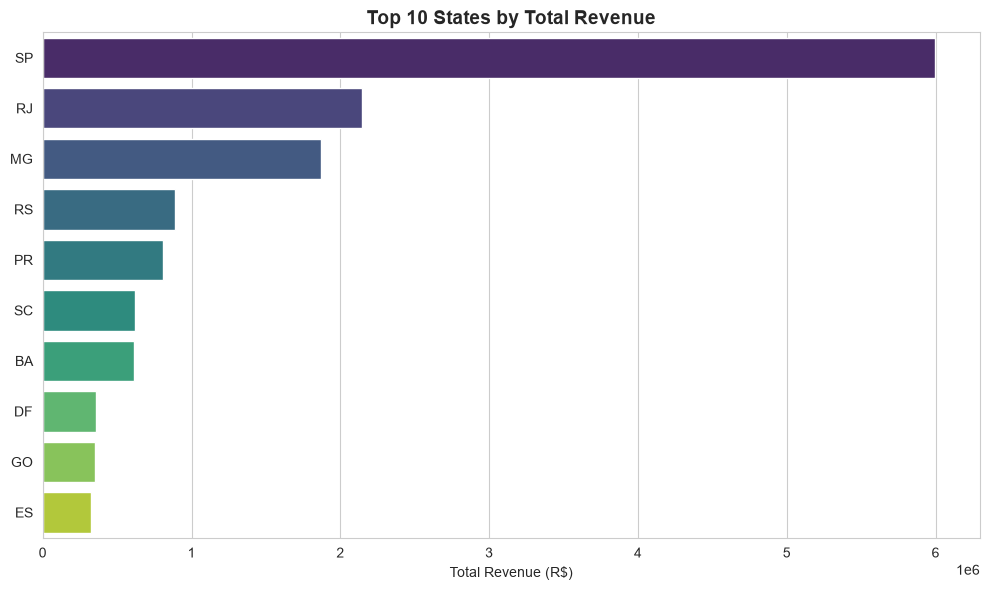

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x='total_revenue', y='customer_state', data=revenue_df, palette="viridis")
plt.title("Top 10 States by Total Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Total Revenue (R$)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("images/top_revenue_by_state.png")
plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

C:\Users\keshe\AppData\Local\Temp\ipykernel_37664\697235416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette="crest")


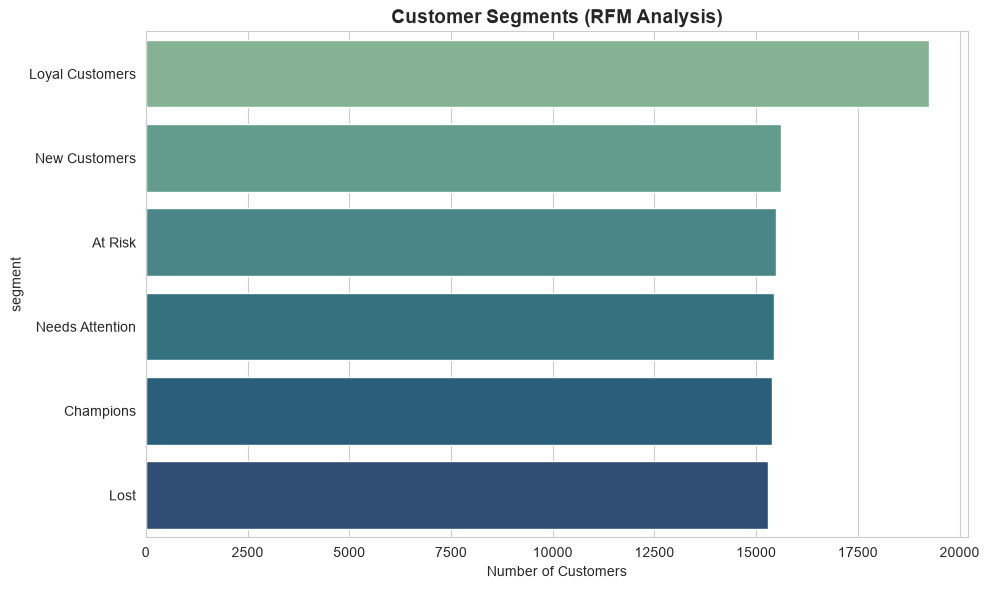

In [19]:
plt.figure(figsize=(10, 6))
segment_counts = rfm_raw['segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette="crest")
plt.title("Customer Segments (RFM Analysis)", fontsize=14, fontweight='bold')
plt.xlabel("Number of Customers")
plt.tight_layout()
plt.savefig("images/rfm_segments.png")
plt.show()

C:\Users\keshe\AppData\Local\Temp\ipykernel_37664\1005487782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='avg_delivery_days', y='customer_state', data=delivery_df.sort_values('avg_delivery_days', ascending=False).head(10), palette="rocket")


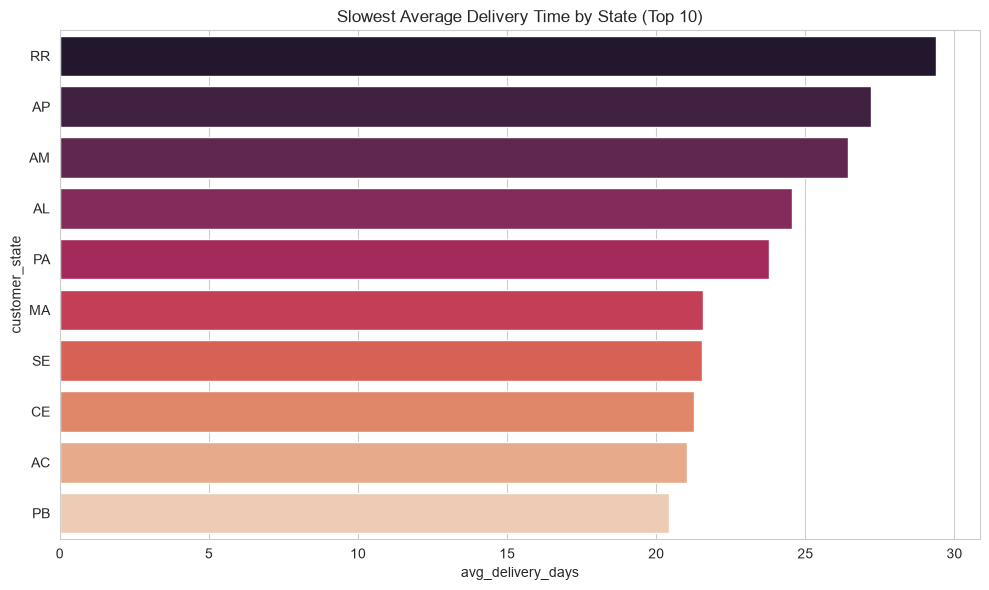

C:\Users\keshe\AppData\Local\Temp\ipykernel_37664\1005487782.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_review', y='customer_state', data=review_df.sort_values('average_review', ascending=False).head(10), palette="mako")


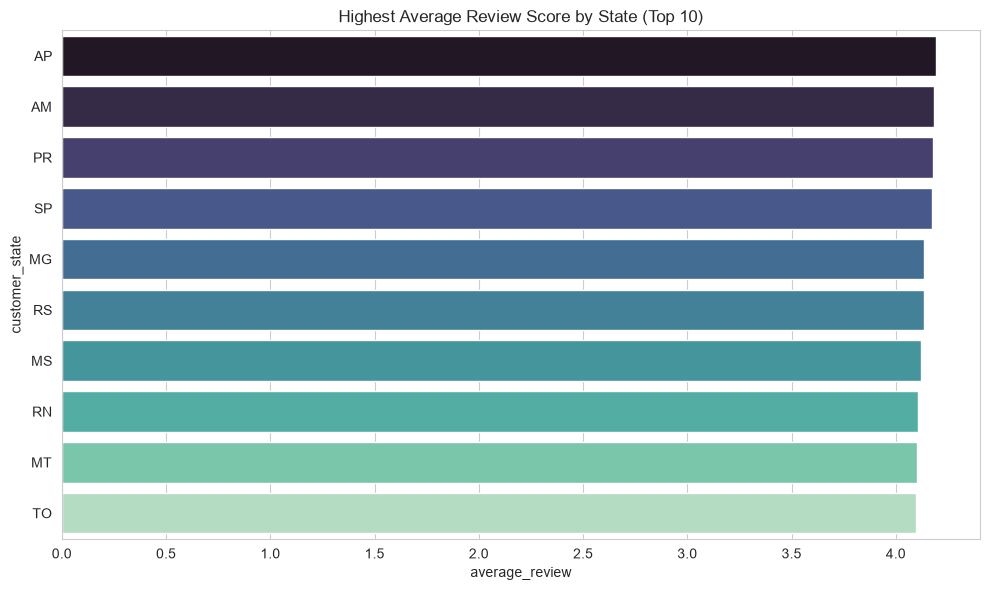

In [20]:
# Delivery time by state
plt.figure(figsize=(10,6))
sns.barplot(x='avg_delivery_days', y='customer_state', data=delivery_df.sort_values('avg_delivery_days', ascending=False).head(10), palette="rocket")
plt.title("Slowest Average Delivery Time by State (Top 10)")
plt.tight_layout()
plt.savefig("images/delivery_time_by_state.png")
plt.show()

# Review score by state
plt.figure(figsize=(10,6))
sns.barplot(x='average_review', y='customer_state', data=review_df.sort_values('average_review', ascending=False).head(10), palette="mako")
plt.title("Highest Average Review Score by State (Top 10)")
plt.tight_layout()
plt.savefig("images/review_score_by_state.png")
plt.show()